# Data

In [1016]:
import pandas as pd

df = pd.read_parquet("../data_raw_clean/models.parquet")[["fullname", "Architecture", "#Params (B)", "cohort"]]
df = df.drop_duplicates(subset="fullname", keep="first")
COHORT = "Q1-2025"
ARCH = "Gemma2ForCausalLM"

df = df[df["Architecture"] == "Gemma2ForCausalLM"]

# LlamaForCausalLM Qwen2ForCausalLM MistralForCausalLM Gemma2ForCausalLM MixtralForCausalLM Qwen2Model Phi3ForCausalLM
df = df[df["cohort"] == "Q1-2025"]

In [990]:
scores = pd.read_parquet("../data_raw_clean/bbh_scores_unique.parquet")

In [991]:
merged = df.merge(scores, left_on="fullname", right_on="model_name", how="inner").drop(columns=['fullname', 'evaluation_date', 'evaluation_date_ts', "Architecture", "#Params (B)", "cohort"])
score_df = merged.set_index('model_name')
score_df_binary = (score_df >= 0.5).astype(int)

print(f"df:     {len(score_df)}")
print(f"scores: {len(scores)}")
print(f"merged: {len(merged)}")

df:     37
scores: 4506
merged: 37


In [992]:
list(score_df.columns.astype(str))
list(score_df.index.astype(str))

['Sakalti/SJT-2B',
 'Sakalti/SJT-2B-V1.1',
 'Sorawiz/Gemma-9B-Base',
 'Sorawiz/Gemma-Creative-9B-Base',
 'Supichi/BBAI_135_Gemma',
 'Triangle104/Gemmadevi-Stock-10B',
 'agentlans/Gemma2-9B-AdvancedFuse',
 'bunnycore/Gemma-2-2B-Smart',
 'jebish7/gemma-2-2b-it',
 'jebish7/gemma-2-9b-it',
 'lkoenig/BBAI_200_Gemma',
 'mergekit-community/mergekit-ties-rraxdhv',
 'prithivMLmods/GWQ-9B-Preview',
 'prithivMLmods/GWQ-9B-Preview2',
 'prithivMLmods/GWQ2b',
 'silma-ai/SILMA-Kashif-2B-Instruct-v1.0',
 'zake7749/gemma-2-9b-it-chinese-kyara',
 'zelk12/MT-Gen6-gemma-2-9B',
 'zelk12/MT-Gen6fix-gemma-2-9B',
 'zelk12/MT-Gen7-gemma-2-9B',
 'zelk12/MT-Max-Merge_02012025163610-gemma-2-9B',
 'zelk12/MT-Merge6-gemma-2-9B',
 'zelk12/MT1-Gen6-gemma-2-9B',
 'zelk12/MT1-Gen7-gemma-2-9B',
 'zelk12/MT1-Max-Merge_02012025163610-gemma-2-9B',
 'zelk12/MT2-Gen6-gemma-2-9B',
 'zelk12/MT2-Gen7-gemma-2-9B',
 'zelk12/MT2-Max-Merge_02012025163610-gemma-2-9B',
 'zelk12/MT3-Gen6-gemma-2-9B',
 'zelk12/MT3-Max-Merge_02012025163

# Call Lib

In [993]:
from torch_measure.data import ResponseMatrix

In [994]:
rm = ResponseMatrix.from_dataframe(score_df)

In [995]:
print(rm.n_subjects)  # number of models
print(rm.n_items)     # should be 24

37
24


In [996]:
rm.data.shape

torch.Size([37, 24])

# Explore Data

In [997]:
import matplotlib.pyplot as plt

from torch_measure.viz import plot_icc, plot_response_heatmap, plot_information

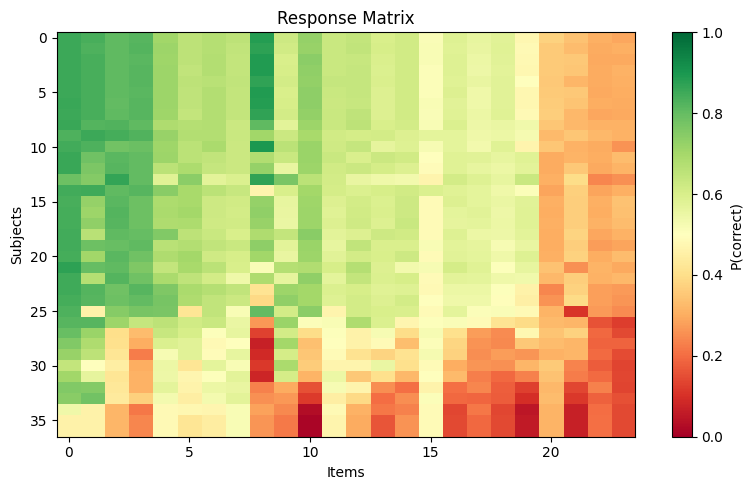

In [998]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_response_heatmap(rm.data, ax=ax)
plt.tight_layout()
plt.show()

In [999]:
# Empirical phi estimate from your mean/std data
# For Beta: var = mu*(1-mu)/(phi+1)  =>  phi = mu*(1-mu)/var - 1

mu = score_df.mean().mean()
var = score_df.std().mean() ** 2

phi_empirical = mu * (1 - mu) / var - 1
print(phi_empirical)


15.008747403781111


# IRT beta 2pl

In [1001]:
device = 'cpu'
data = rm.data.to(device)
mask = rm.observed_mask.to(device)

In [1002]:
rasch = MyBetaRasch(n_subjects=rm.n_subjects, n_items=rm.n_items, device=device)
rasch_history = rasch.fit(data, mask=mask, max_epochs=10000, verbose=True)

MLE fitting:   6%|▌         | 594/10000 [00:00<00:06, 1391.45it/s, loss=-0.833268]


In [1003]:
twopl = MyBetaTwoPL(n_subjects=rm.n_subjects, n_items=rm.n_items, device=device)
twopl_history = twopl.fit(data, mask=mask, max_epochs=10000, verbose=True)

MLE fitting:  15%|█▍        | 1488/10000 [00:01<00:06, 1337.99it/s, loss=-0.936642]


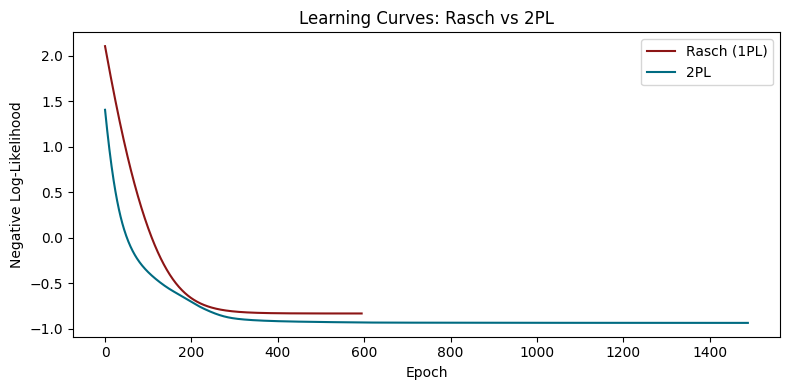

Rasch final loss: -0.8333
2PL   final loss: -0.9366


In [1004]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rasch_history["losses"], color="#8C1515", linewidth=1.5, label="Rasch (1PL)")
ax.plot(twopl_history["losses"], color="#006B81", linewidth=1.5, label="2PL")
ax.set_xlabel("Epoch")
ax.set_ylabel("Negative Log-Likelihood")
ax.set_title("Learning Curves: Rasch vs 2PL")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Rasch final loss: {rasch_history['losses'][-1]:.4f}")
print(f"2PL   final loss: {twopl_history['losses'][-1]:.4f}")

In [1005]:
# Rasch parameters
abilities = rasch.ability.detach().cpu()
difficulties = rasch.difficulty.detach().cpu()

# 2PL parameters
abilities_2pl = twopl.ability.detach().cpu()
difficulties_2pl = twopl.difficulty.detach().cpu()
discriminations_2pl = twopl.discrimination.detach().cpu()

print(f"Rasch abilities:       min = {abilities.min():.2f}, max = {abilities.max():.2f}")
print(f"Rasch difficulties:    min = {difficulties.min():.2f}, max = {difficulties.max():.2f}")
print(f"\n2PL abilities:         min = {abilities_2pl.min():.2f}, max = {abilities_2pl.max():.2f}")
print(f"2PL difficulties:      min = {difficulties_2pl.min():.2f}, max = {difficulties_2pl.max():.2f}")
print(f"2PL discriminations:   min = {discriminations_2pl.min():.2f}, max = {discriminations_2pl.max():.2f}, "
      f"mean = {discriminations_2pl.mean():.2f}")
print(f"\n(Rasch assumes discrimination = 1 for all items; 2PL estimates it per item)")

Rasch abilities:       min = -0.86, max = 0.64
Rasch difficulties:    min = -0.96, max = 1.29

2PL abilities:         min = -1.03, max = 0.25
2PL difficulties:      min = -1.31, max = 1.83
2PL discriminations:   min = 0.09, max = 3.04, mean = 1.14

(Rasch assumes discrimination = 1 for all items; 2PL estimates it per item)


# Post Analysis

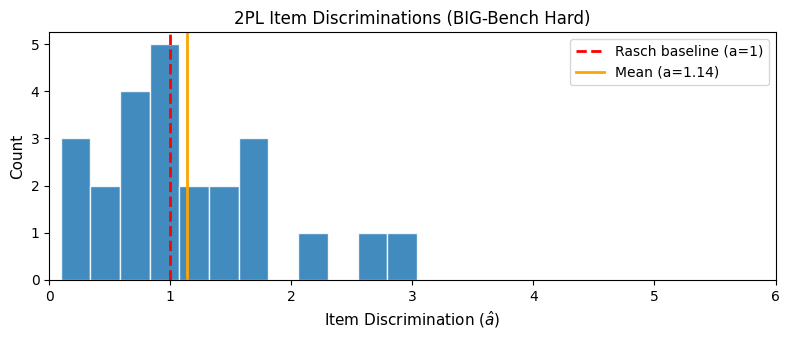

Discrimination range: 0.09 to 3.04
Mean: 1.14, Std: 0.73


In [1006]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(discriminations_2pl.numpy(), bins=12, alpha=0.85, edgecolor='white')
ax.axvline(x=1.0, linestyle="--", linewidth=2, color='red', label="Rasch baseline (a=1)")
ax.axvline(x=discriminations_2pl.mean().item(), linestyle="-", linewidth=2,
           color='orange', label=f"Mean (a={discriminations_2pl.mean().item():.2f})")
ax.set_xlabel(r"Item Discrimination ($\hat{a}$)", fontsize=11)
ax.set_xlim(0, 6)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("2PL Item Discriminations (BIG-Bench Hard)", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Discrimination range: {discriminations_2pl.min():.2f} to {discriminations_2pl.max():.2f}")
print(f"Mean: {discriminations_2pl.mean():.2f}, Std: {discriminations_2pl.std():.2f}")

In [1007]:
# discriminations_2pl

In [1008]:
# import numpy as np
# a = discriminations_2pl.detach().numpy()
# a_log = np.log(a)
# a_log_z = (a_log - a_log.mean()) / a_log.std()
# 
# a_log_z

In [1009]:
# discriminations_2pl_mean = discriminations_2pl.mean()
# discriminations_2pl_std  = discriminations_2pl.std()
# 
# discriminations_2pl_z = (discriminations_2pl - discriminations_2pl_mean) / discriminations_2pl_std
# 
# discriminations_2pl_z

In [1010]:
import numpy as np

a = discriminations_2pl.detach().numpy()

median = np.median(a)
mad    = np.median(np.abs(a - median))
z_mad  = (a - median) / (1.4826 * mad)  # 1.4826 使其与正态 std 一致

z_mad

array([ 0.12930079, -1.1408665 ,  0.42953986,  0.0182945 , -0.86353546,
        1.2655855 , -0.45272923,  0.7053517 ,  1.0798877 ,  1.4555857 ,
       -0.15038589, -0.38905817, -0.0182946 ,  0.48943216,  2.8986547 ,
        2.2299101 ,  0.8122578 , -0.58672845, -0.10091381,  3.6270242 ,
       -0.64362985, -0.2968641 , -1.0567248 , -1.4787576 ], dtype=float32)

In [1011]:
from scipy.stats import rankdata
discriminations_2pl_prank = rankdata(discriminations_2pl) / len(discriminations_2pl)
discriminations_2pl_prank

array([0.58333333, 0.08333333, 0.625     , 0.54166667, 0.16666667,
       0.83333333, 0.29166667, 0.70833333, 0.79166667, 0.875     ,
       0.41666667, 0.33333333, 0.5       , 0.66666667, 0.95833333,
       0.91666667, 0.75      , 0.25      , 0.45833333, 1.        ,
       0.20833333, 0.375     , 0.125     , 0.04166667])

In [1028]:
items = [
      'boolean_expressions', 'causal_judgement', 'date_understanding', 'disambiguation_qa',
      'formal_fallacies', 'geometric_shapes', 'hyperbaton', 'logical_deduction_5obj',
      'logical_deduction_7obj', 'logical_deduction_3obj', 'movie_recommendation',
      'navigate', 'object_counting', 'penguins_in_table', 'reasoning_colored_obj',
      'ruin_names', 'salient_translation', 'snarks', 'sports_understanding',
      'temporal_sequences', 'tracking_5obj', 'tracking_7obj', 'tracking_3obj', 'web_of_lies'
]

def save(nparr, name):
    path = f'../data_irt/BBH/{name}.csv'
    df = pd.read_csv(path)
    mask = (df['cohort'] == COHORT) & (df['arch'] == ARCH)
    if mask.any():
            # Update existing row
            df.loc[mask, items] = nparr
            print(f"Updated existing row where cohort='{COHORT}' and arch='{ARCH}'")
    else:
            # Create new row and append
            new_row = pd.DataFrame([nparr], columns=items)
            new_row['cohort'] = COHORT
            new_row['arch'] = ARCH
            df = pd.concat([df, new_row], ignore_index=True)
            print(f"Added new row since cohort='{COHORT}' and arch='{ARCH} didn't exist")

    df.to_csv(path, index=False)

In [1029]:
save(discriminations_2pl_prank, "discriminations_2pl_prank")

Updated existing row where cohort='Q1-2025' and arch='Gemma2ForCausalLM'


In [1012]:
# difficulties_2pl

In [1013]:
# difficulties_2pl_mean = difficulties_2pl.mean()
# difficulties_2pl_std  = difficulties_2pl.std()
# 
# difficulties_2pl_z = (difficulties_2pl - difficulties_2pl_mean) / difficulties_2pl_std
# 
# difficulties_2pl_z

In [1014]:
from scipy.stats import rankdata
difficulties_2pl_prank = rankdata(difficulties_2pl) / len(difficulties_2pl)
difficulties_2pl_prank

array([0.08333333, 0.04166667, 0.625     , 0.45833333, 0.29166667,
       0.83333333, 0.16666667, 0.75      , 0.79166667, 0.33333333,
       0.375     , 0.25      , 0.875     , 0.66666667, 0.54166667,
       0.41666667, 0.70833333, 0.20833333, 0.125     , 0.58333333,
       0.95833333, 0.91666667, 1.        , 0.5       ])